In [1]:
import os
os.chdir("..")

In [ ]:
from torchvision import transforms
import torch, random, math
import torch.nn.functional as F

from data.data import build_byol_transforms, FG_MEAN, FG_STD, ssl_ds, ga_normalize, in_normalize
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils.utils import GaussianBlur, AdditiveGaussianNoise

# ---- Main builder ----
# --- put these near your imports ---
import math
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import torch
from torchvision import transforms
import torchvision.transforms.functional as F

class PSFGaussianBlur:
    """
    Small Gaussian blur to mimic atmospheric seeing / PSF.
    sigma sampled in [sigma_min, sigma_max]; kernel auto-picked from sigma.
    Works on PIL images.
    """
    def __init__(self, sigma=(0.5, 1.5)):
        self.sigma = sigma

    def __call__(self, img: Image.Image) -> Image.Image:
        s = random.uniform(*self.sigma)
        # PIL's GaussianBlur uses radius ~ sigma
        return img.filter(ImageFilter.GaussianBlur(radius=s))

class PoissonNoise:
    """
    Photon-counting (Poisson) noise. Works on tensors in [0,1].
    We simulate a 'counts scale': counts = x * scale, sample Poisson, then divide back.
    """
    def __init__(self, scale_range=(500.0, 2000.0)):
        self.scale_range = scale_range

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # x is Tensor [C,H,W] in [0,1]
        if not torch.is_tensor(x):
            raise TypeError("PoissonNoise expects a Tensor after ToTensor().")
        scale = float(random.uniform(*self.scale_range))
        counts = (x * scale).clamp(min=0.0)
        noisy = torch.poisson(counts) / scale
        return noisy.clamp(0.0, 1.0)

class CosmicRayArtifacts:
    """
    Rare bright spots and occasional streaks (on PIL image), then return PIL.
    - prob_per_pixel controls random 'hot pixel' mask (like your function)
    - streaks add 0-2 bright lines
    """
    def __init__(self,
                 p_apply=0.15,
                 prob_per_pixel=0.001,
                 max_streaks=2,
                 spot_intensity=(0.8, 1.0),
                 streak_intensity=(0.7, 1.0),
                 streak_thickness=(1, 2)):
        self.p_apply = p_apply
        self.prob_per_pixel = prob_per_pixel
        self.max_streaks = max_streaks
        self.spot_intensity = spot_intensity
        self.streak_intensity = streak_intensity
        self.streak_thickness = streak_thickness

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() > self.p_apply:
            return img

        # --- bright spots via your numpy-mask method ---
        arr = np.asarray(img).astype(np.float32) / 255.0
        h, w = arr.shape[:2]
        mask = (np.random.random((h, w)) < self.prob_per_pixel).astype(np.float32)
        # same mask for all channels
        spot_val = np.random.uniform(*self.spot_intensity, size=(h, w, 1)).astype(np.float32)
        arr = np.clip(arr * (1 - mask[..., None]) + spot_val * mask[..., None], 0.0, 1.0)
        img = Image.fromarray((arr * 255.0).astype(np.uint8))

        # --- occasional short streaks ---
        draw = ImageDraw.Draw(img)
        for _ in range(random.randint(0, self.max_streaks)):
            x1, y1 = random.randint(0, w - 1), random.randint(0, h - 1)
            # keep streaks short-ish
            x2 = int(np.clip(x1 + np.random.randint(-w // 6, w // 6), 0, w - 1))
            y2 = int(np.clip(y1 + np.random.randint(-h // 6, h // 6), 0, h - 1))
            val = int(255 * random.uniform(*self.streak_intensity))
            t = random.randint(*self.streak_thickness)
            draw.line([(x1, y1), (x2, y2)], fill=(val, val, val), width=t)

        return img

# Fallback if you don't already have this in your codebase
class AdditiveGaussianNoise:
    def __init__(self, std=0.02):
        self.std = std
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if not torch.is_tensor(x):
            raise TypeError("AdditiveGaussianNoise expects a Tensor after ToTensor().")
        return (x + torch.randn_like(x) * self.std).clamp(0.0, 1.0)

def build_galaxy_aware_transforms(
    crop_min: float,
    img_size: int = 224,
    flips: bool = True,
    rotations: bool = True,
    normalization: str = "IN"
):
    """
    Constructs two-view data augmentation pipelines tailored for galaxy images.

    Args:
        crop_min: Minimum scale for RandomResizedCrop.
        img_size: Target image size.
        flips: If True, applies random horizontal and vertical flips.
        rotations: If True, applies random 180-degree rotations.
        psf_mode: The PSF model to use ('gaussian', 'moffat', or 'none').
        normalization: The normalization scheme to use ('IN' or 'GA').
    """
    # --- Base transforms applied to both strong and weak views ---
    base_transforms = []
    if rotations:
        base_transforms.append(transforms.RandomRotation(degrees=180, fill=0))
    base_transforms.append(transforms.RandomResizedCrop(img_size, scale=(crop_min, 1.0), ratio=(0.95, 1.05)))
    if flips:
        base_transforms.extend([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5)
        ])
    
    # Photometric transforms are also shared
    base_transforms.extend([
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.15, hue=0.02)
        ], p=0.5),
        transforms.RandomGrayscale(p=0.05)
    ])

    # --- Select the PSF blur model based on the switch ---
    psf_blur_transform = PSFGaussianBlur(sigma=(0.5, 1.5))

    # Choose normalization
    norm_transform = in_normalize if normalization.upper() == "IN" else ga_normalize

    # --- Define transforms specific to each view ---
    
    # Strong view (View 1)
    strong_specific_transforms = [
        CosmicRayArtifacts(p_apply=0.15, prob_per_pixel=0.001, max_streaks=2),
    ]
    if psf_blur_transform:
        # Apply the chosen PSF blur with high probability
        strong_specific_transforms.append(transforms.RandomApply([psf_blur_transform], p=0.9))
        
    strong_specific_transforms.extend([
        transforms.ToTensor(),
        transforms.RandomApply([PoissonNoise(scale_range=(500.0, 2000.0))], p=0.8),
        transforms.RandomApply([AdditiveGaussianNoise(std=0.02)], p=0.3),
        norm_transform
    ])
    
    # Weak view (View 2)
    weak_specific_transforms = [
        CosmicRayArtifacts(p_apply=0.05, prob_per_pixel=0.0005, max_streaks=1),
    ]
    if psf_blur_transform:
        # Apply the chosen PSF blur with low probability
        weak_specific_transforms.append(transforms.RandomApply([psf_blur_transform], p=0.15))

    weak_specific_transforms.extend([
        transforms.ToTensor(),
        norm_transform
    ])

    # Combine base and specific transforms
    strong_pipeline = transforms.Compose(base_transforms + strong_specific_transforms)
    weak_pipeline = transforms.Compose(base_transforms + weak_specific_transforms)

    return strong_pipeline, weak_pipeline



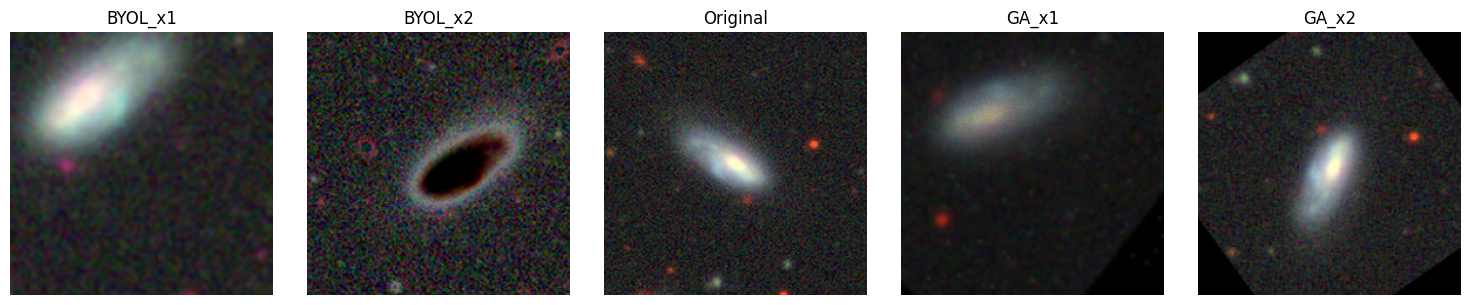

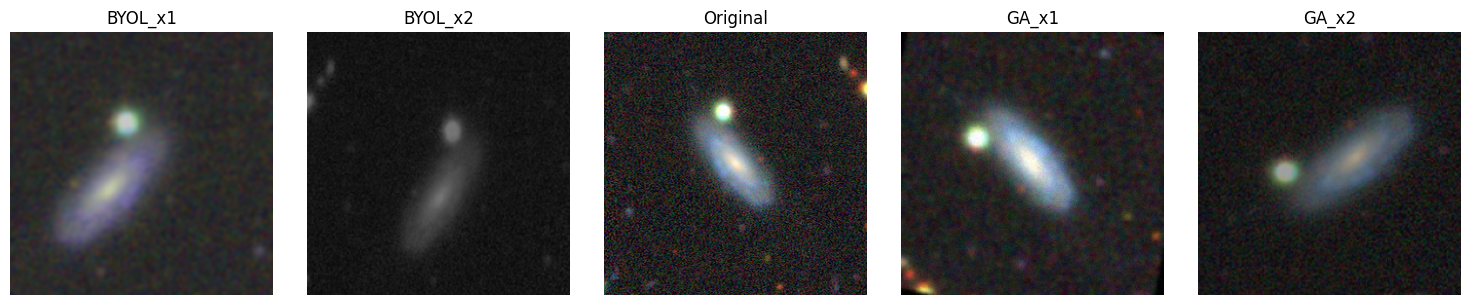

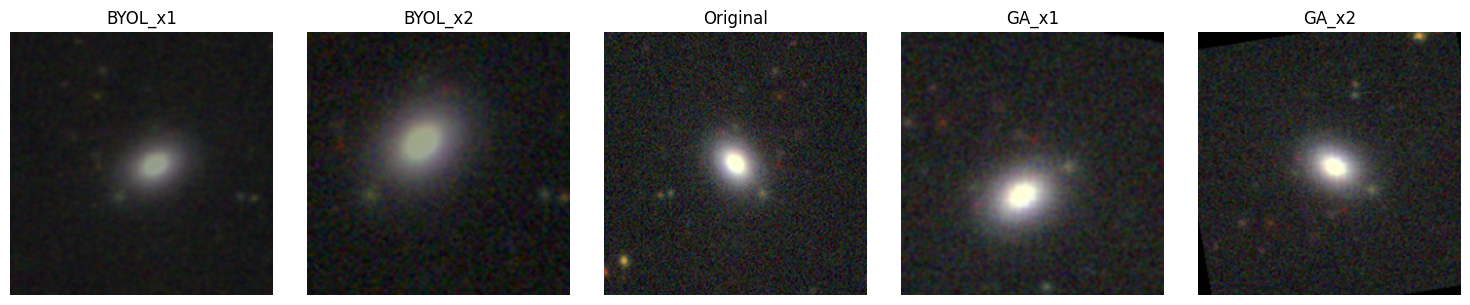

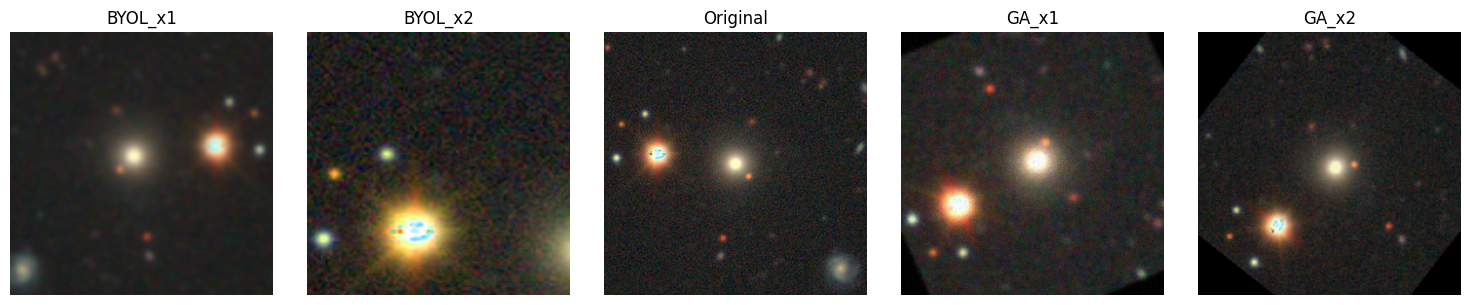

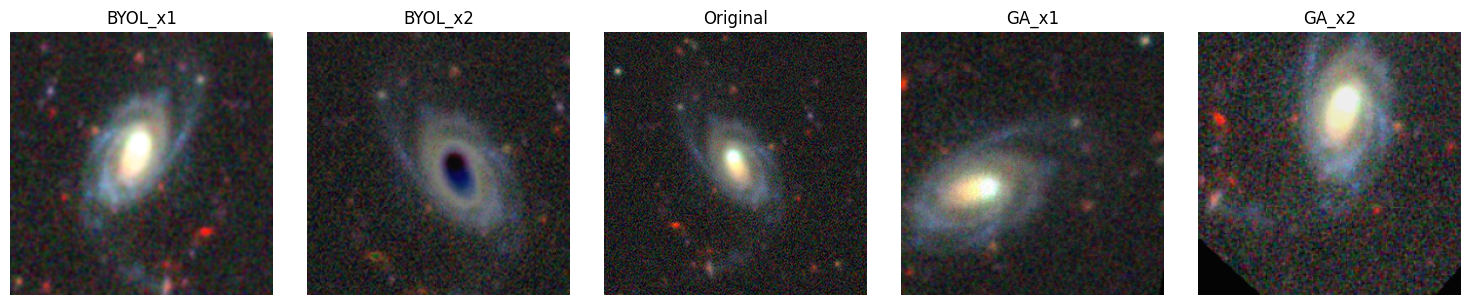

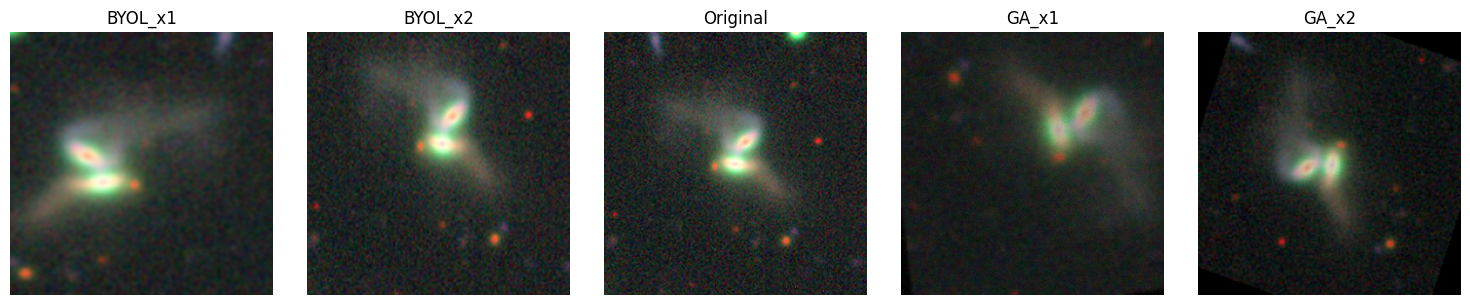

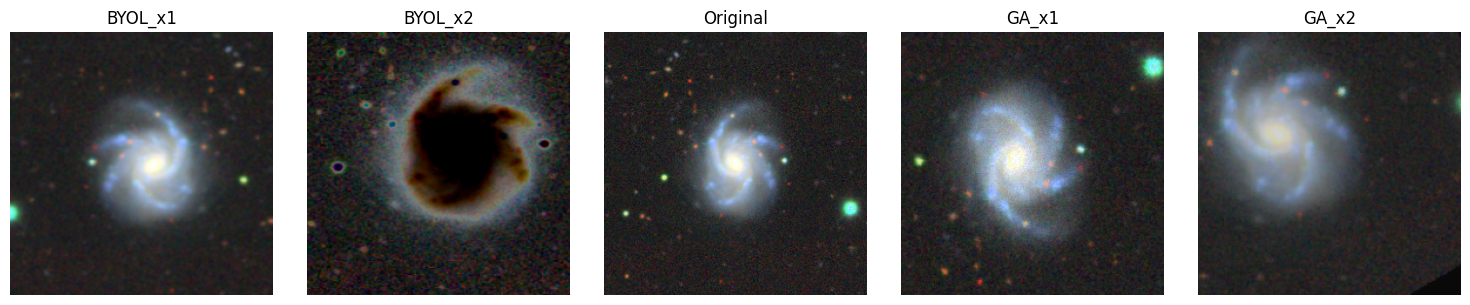

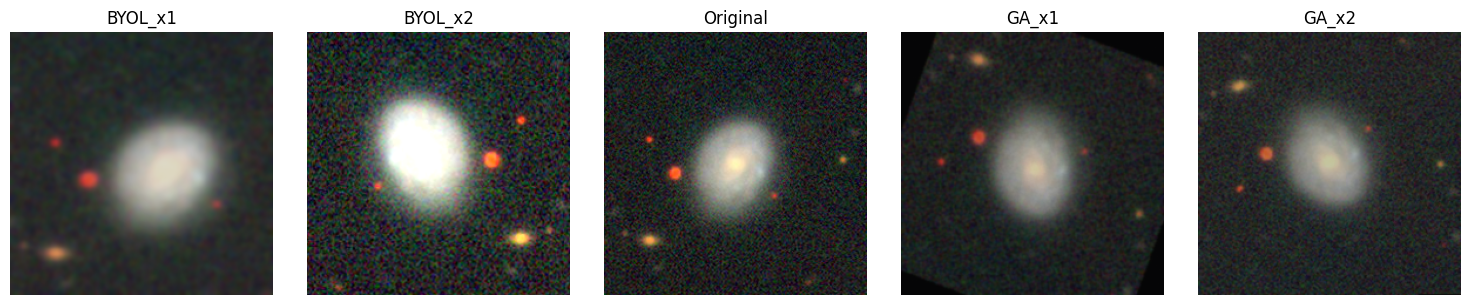

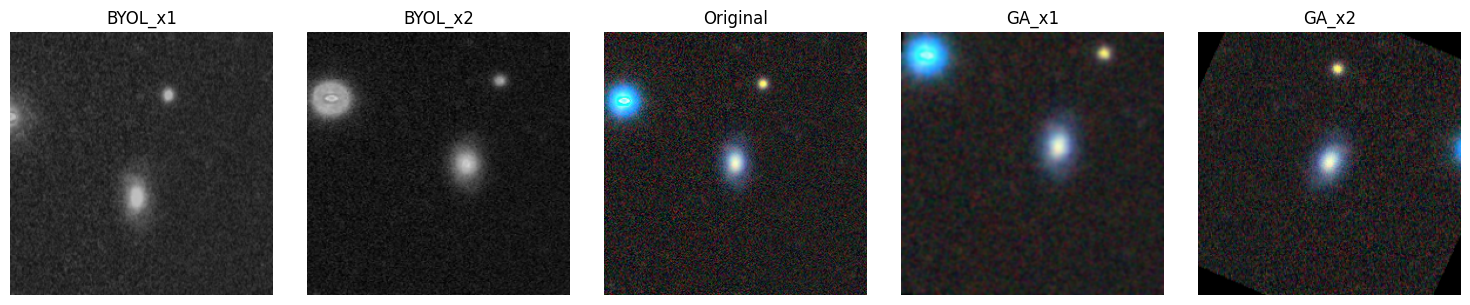

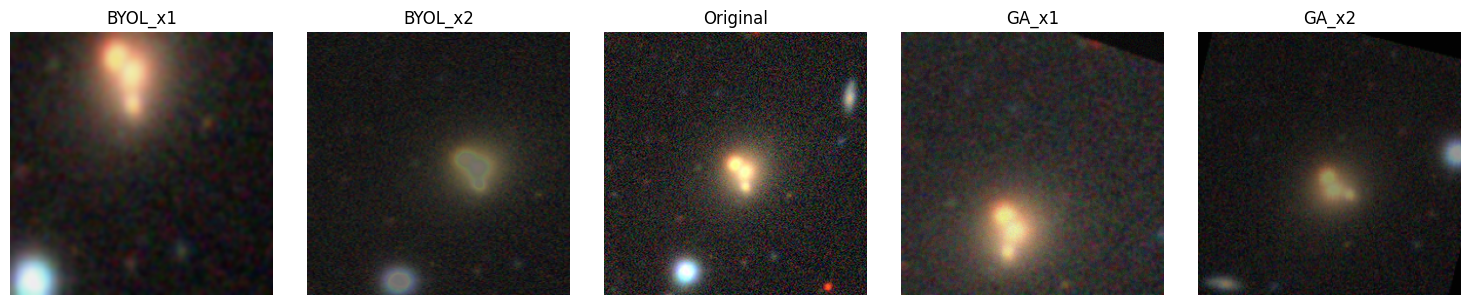

In [11]:
# build transforms
byol_t1, byol_t2 = build_byol_transforms(crop_min=0.2, img_size=224)
ga_t1, ga_t2     = build_galaxy_aware_transforms(crop_min=0.4, 
                                                 img_size=224, 
                                                 normalization="GA")  

class Denormalize:
    def __init__(self, mean, std):
        self.mean = torch.as_tensor(mean)[:, None, None]
        self.std  = torch.as_tensor(std)[:, None, None]
        
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        # move to the right device/dtype
        mean = self.mean.to(device=t.device, dtype=t.dtype)
        std  = self.std.to(device=t.device, dtype=t.dtype)
        return t * std + mean

denorm = Denormalize(mean=FG_MEAN,
                     std=FG_STD)  # calculated based on dataset

byol_denorm = Denormalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])  # ImageNet stats

# ---- visualize a few samples ----
def to_disp(t: torch.Tensor, denorm=denorm) -> np.ndarray:
    """Denormalize and convert CHW tensor to HWC uint8-like float image [0,1]."""
    t = denorm(t.clone())
    t = t.clamp(0, 1)
    return t.permute(1, 2, 0).cpu().numpy()

for img in ssl_ds["train"]["image"][:10]:  # PIL images
    byol_x1 = byol_t1(img)
    byol_x2 = byol_t2(img)
    ga_x1   = ga_t1(img)
    ga_x2   = ga_t2(img)
    
    imgs   = [byol_x1, byol_x2, img, ga_x1, ga_x2]
    titles = ["BYOL_x1", "BYOL_x2", "Original", "GA_x1", "GA_x2"]

    plt.figure(figsize=(15, 3))
    for i, (im, title) in enumerate(zip(imgs, titles)):
        plt.subplot(1, 5, i + 1)
        if isinstance(im, torch.Tensor):   # transformed (normalized) tensor
            im = to_disp(im, denorm=byol_denorm if "BYOL" in title else denorm)
        else:                              # original PIL
            im = np.asarray(im)
        plt.imshow(im)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()